Saved → arctic_polygons.png


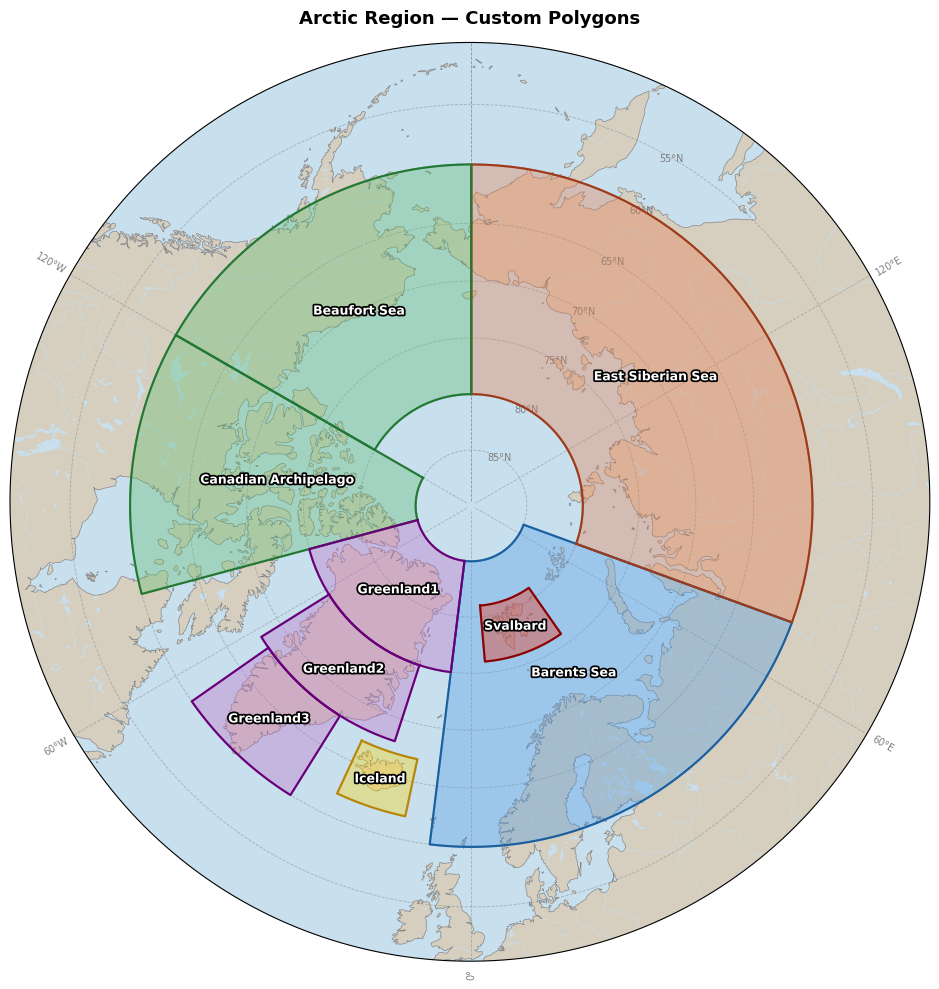

In [27]:
"""
Arctic Polar Stereographic Map with Labelled Polygons
======================================================
Draws user-defined polygons (by lat/lon extent) on an Arctic map
using a North Polar Stereographic projection via Cartopy.

Requirements:
    pip install cartopy matplotlib shapely

Usage:
    Edit the POLYGONS list below, then run:
        python arctic_polygons.py
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import transform as shapely_transform


# =============================================================================
# DEFINE YOUR POLYGONS HERE
# Each polygon is a dict with:
#   - "label"   : text label shown at polygon centroid
#   - "lons"    : list of longitudes  (can also use a [lon_min, lon_max] pair
#                 combined with lats for a simple rectangular extent)
#   - "lats"    : list of latitudes   (same length as lons, or use helper below)
#   - "color"   : face colour (any matplotlib colour string or hex)
#   - "alpha"   : transparency 0–1
#   - "edgecolor": border colour
#
# Helper: use `rect_polygon(lon_min, lon_max, lat_min, lat_max, n=50)` to
# build a smooth rectangular extent (curves correctly in polar projection).
# =============================================================================

def rect_polygon(lon_min, lon_max, lat_min, lat_max, n=50):
    """
    Return (lons, lats) for a 'rectangular' lat/lon box that renders
    correctly in a polar stereographic projection by densifying the edges.
    """
    top    = (np.linspace(lon_min, lon_max, n), np.full(n, lat_max))
    right  = (np.full(n, lon_max), np.linspace(lat_max, lat_min, n))
    bottom = (np.linspace(lon_max, lon_min, n), np.full(n, lat_min))
    left   = (np.full(n, lon_min), np.linspace(lat_min, lat_max, n))
    lons = np.concatenate([top[0], right[0], bottom[0], left[0]])
    lats = np.concatenate([top[1], right[1], bottom[1], left[1]])
    return lons.tolist(), lats.tolist()


# --- Example polygons — edit or replace these freely ---

_lons1, _lats1 = rect_polygon(-7, 70, 60, 85)
_lons2, _lats2 = rect_polygon(70, 180, 60, 80)
_lons3, _lats3 = rect_polygon(-120, -75, 60, 85)
_lons4, _lats4 = rect_polygon(-75, -7, 75, 85)
_lons5, _lats5 = rect_polygon(-180, -120, 60, 80)
_lons6, _lats6 = rect_polygon(-58, -18, 68, 75)
_lons7, _lats7 = rect_polygon(-55, -32, 60, 68)
_lons8, _lats8 = rect_polygon(-25, -12, 62, 67)
_lons9, _lats9 = rect_polygon(5, 35, 76, 81)

POLYGONS = [
    {
        "label":     "Barents Sea",
        "lons":      _lons1,
        "lats":      _lats1,
        "color":     "#4C9BE8",
        "alpha":     0.35,
        "edgecolor": "#1A5F9E",
    },
    {
        "label":     "East Siberian Sea",
        "lons":      _lons2,
        "lats":      _lats2,
        "color":     "#E87B4C",
        "alpha":     0.35,
        "edgecolor": "#9E3A1A",
    },
    {
        "label":     "Canadian Archipelago",
        "lons":      _lons3,
        "lats":      _lats3,
        "color":     "#5DBE6E",
        "alpha":     0.35,
        "edgecolor": "#237833",
    },
    {
        "label":     "Beaufort Sea",
        "lons":      _lons5,
        "lats":      _lats5,
        "color":     "#5DBE6E",
        "alpha":     0.35,
        "edgecolor": "#237833",
    },
    {
        "label":     "Greenland1",
        "lons":      _lons4,
        "lats":      _lats4,
        "color":     "#C06BC9",
        "alpha":     0.35,
        "edgecolor": "#6A0079",
    },
    {
        "label":     "Greenland2",
        "lons":      _lons6,
        "lats":      _lats6,
        "color":     "#C06BC9",
        "alpha":     0.35,
        "edgecolor": "#6A0079",
    },
    {
        "label":     "Greenland3",
        "lons":      _lons7,
        "lats":      _lats7,
        "color":     "#C06BC9",
        "alpha":     0.35,
        "edgecolor": "#6A0079",
    },
    {
        "label":     "Iceland",
        "lons":      _lons8,
        "lats":      _lats8,
        "color":     "#FFD700",
        "alpha":     0.35,
        "edgecolor": "#B8860B",
    },
    {
        "label":     "Svalbard",
        "lons":      _lons9,
        "lats":      _lats9,
        "color":     "#FF2400",
        "alpha":     0.35,
        "edgecolor": "#8B0000",
    },
    # --- arbitrary custom polygon (irregular shape) ---
    # {
    #     "label":     "Custom Region",
    #     "lons":      [-20, 20, 30, 0, -30],
    #     "lats":      [83, 84, 88, 90, 87],
    #     "color":     "#FFD700",
    #     "alpha":     0.45,
    #     "edgecolor": "#B8860B",
    # },
]


# =============================================================================
# MAP SETTINGS  — adjust to taste
# =============================================================================

PROJECTION       = ccrs.NorthPolarStereo()   # North Polar Stereographic
EXTENT_LATITUDE  = 50                         # show everything north of this °
MAP_RESOLUTION   = "50m"                      # "10m", "50m", or "110m"

LABEL_FONTSIZE   = 9
LABEL_FONTWEIGHT = "bold"
LABEL_COLOR      = "white"
LABEL_OUTLINE    = "black"                    # halo colour around text

FIGSIZE          = (10, 10)
TITLE            = "Arctic Region — Custom Polygons"
OUTPUT_FILE      = "arctic_polygons.png"      # set to None to display interactively
DPI              = 200


# =============================================================================
# PLOTTING
# =============================================================================

def compute_label_position(lons, lats):
    """
    Return the centroid (lon, lat) of a polygon defined by coordinate lists.
    Uses shapely for a proper centroid even for irregular shapes.
    """
    poly = Polygon(zip(lons, lats))
    c = poly.centroid
    return c.x, c.y


def draw_map():
    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        subplot_kw={"projection": PROJECTION},
    )

    # --- Set circular Arctic extent ---
    ax.set_extent([-180, 180, EXTENT_LATITUDE, 90], crs=ccrs.PlateCarree())

    # --- Natural Earth background features ---
    ax.add_feature(cfeature.NaturalEarthFeature(
        "physical", "ocean", MAP_RESOLUTION,
        facecolor="#C8DFED", edgecolor="none"
    ))
    ax.add_feature(cfeature.NaturalEarthFeature(
        "physical", "land", MAP_RESOLUTION,
        facecolor="#D6CFC0", edgecolor="#888888", linewidth=0.5
    ))
    ax.add_feature(cfeature.NaturalEarthFeature(
        "physical", "lakes", MAP_RESOLUTION,
        facecolor="#C8DFED", edgecolor="none"
    ))
    ax.add_feature(cfeature.NaturalEarthFeature(
        "physical", "rivers_lake_centerlines", MAP_RESOLUTION,
        facecolor="none", edgecolor="#C8DFED", linewidth=0.4
    ))

    # --- Gridlines ---
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.6,
        color="grey",
        alpha=0.5,
        linestyle="--",
        x_inline=False,
        y_inline=True,
    )
    gl.top_labels    = False
    gl.right_labels  = False
    gl.xlabel_style  = {"size": 7, "color": "grey"}
    gl.ylabel_style  = {"size": 7, "color": "grey"}

    # --- Draw polygons ---
    transform = ccrs.PlateCarree()

    for poly in POLYGONS:
        lons      = poly["lons"]
        lats      = poly["lats"]
        color     = poly.get("color", "steelblue")
        alpha     = poly.get("alpha", 0.4)
        edgecolor = poly.get("edgecolor", "navy")
        label     = poly.get("label", "")

        # Fill polygon
        ax.fill(
            lons, lats,
            transform=transform,
            facecolor=color,
            alpha=alpha,
            edgecolor=edgecolor,
            linewidth=1.5,
            zorder=4,
        )

        # Outline with full opacity
        ax.plot(
            lons + [lons[0]],
            lats + [lats[0]],
            transform=transform,
            color=edgecolor,
            linewidth=1.5,
            zorder=5,
        )

        # Label at centroid
        if label:
            clon, clat = compute_label_position(lons, lats)
            ax.text(
                clon, clat, label,
                transform=transform,
                fontsize=LABEL_FONTSIZE,
                fontweight=LABEL_FONTWEIGHT,
                color=LABEL_COLOR,
                ha="center", va="center",
                zorder=6,
                path_effects=[
                    pe.withStroke(linewidth=2.5, foreground=LABEL_OUTLINE)
                ],
            )

    # --- Circular boundary clip ---
    import matplotlib.path as mpath
    theta = np.linspace(0, 2 * np.pi, 300)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_title(TITLE, fontsize=13, fontweight="bold", pad=14)

    plt.tight_layout()

    if OUTPUT_FILE:
        plt.savefig(OUTPUT_FILE, dpi=DPI, bbox_inches="tight")
        print(f"Saved → {OUTPUT_FILE}")
    else:
        plt.show()


if __name__ == "__main__":
    draw_map()